**Task** : The task is to build a Machine Learning model that can predict the future sales of a product based on advertising expenditure on different platforms such as:

* TV advertisements
* Radio advertisements
* Newspaper advertisements

> **Problem Statement**

The problem is to build a Machine Learning model that predicts product sales based on advertising expenditure across different platforms such as TV, Radio, and Newspaper. The model helps businesses analyze the impact of advertising on sales and make data-driven marketing decisions.

> **Objective**

The main objective of this project is:

To analyze the relationship between advertising spending and product sales, and build a model that accurately predicts future sales.

**Libraries Requirements**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

> **Loading Dataset**

In [35]:
data = pd.read_csv("Advertising.csv")

In [36]:
df = pd.DataFrame(data)

> **Exploring The Data**

In [37]:
type(df)

pandas.core.frame.DataFrame

In [38]:
print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [39]:
type(df)

pandas.core.frame.DataFrame

In [40]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [41]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [42]:
df.value_counts()

,,,,,count
Unnamed: 0,TV,Radio,Newspaper,Sales,
1,230.1,37.8,69.2,22.1,1
2,44.5,39.3,45.1,10.4,1
3,17.2,45.9,69.3,9.3,1
4,151.5,41.3,58.5,18.5,1
5,180.8,10.8,58.4,12.9,1
...,...,...,...,...,...
196,38.2,3.7,13.8,7.6,1
197,94.2,4.9,8.1,9.7,1
198,177.0,9.3,6.4,12.8,1


In [43]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [44]:
df.dtypes

,0
Unnamed: 0,int64
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [45]:
df.shape

(200, 5)

> **Data Cleaning**

In [46]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [47]:
df.isna().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [48]:
df.fillna(data.mean(), inplace=True)

In [49]:
print(df.duplicated().sum())

0


> **Data Visualization**

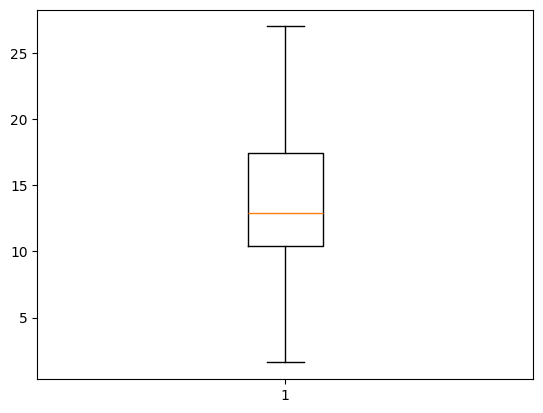

In [50]:
import matplotlib.pyplot as plt

plt.boxplot(df['Sales'])
plt.show()

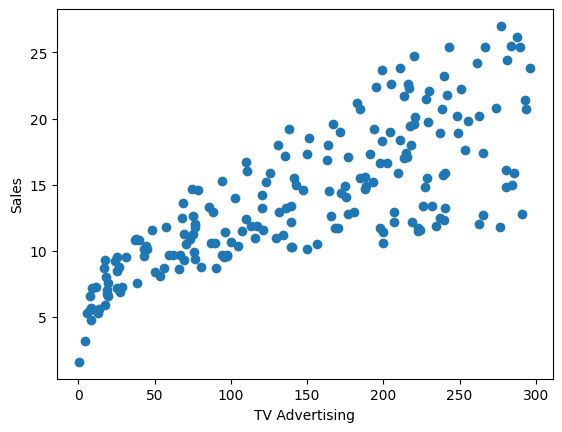

In [51]:
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

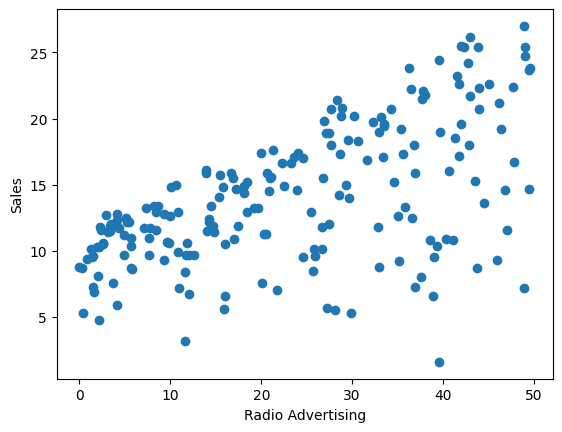

In [52]:
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

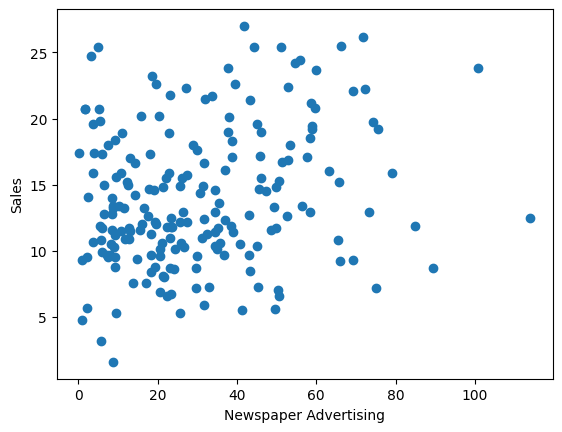

In [53]:
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()



*  **Heatmap**


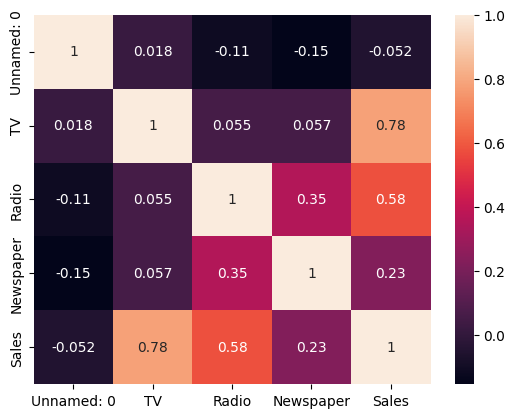

In [54]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

In [55]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

> **Train-Test Split**

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

> **Model Training**

In [57]:
from sklearn.ensemble import RandomForestRegressor

In [58]:
rf = RandomForestRegressor(n_estimators=300,max_depth=15,random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=300, random_state=42)

> **Model Evaluation**

In [59]:
y_pred = rf.predict(X_test)

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("R2 Score:", r2)
print("RMSE:", rmse)

MSE: 0.5480964194444423
R2 Score: 0.9826351706404014
RMSE: 0.740335342560682


In [61]:
importance = rf.feature_importances_

feature_names = X.columns

for i, v in enumerate(importance):
    print(feature_names[i], ":", v)

TV : 0.6254472165625853
Radio : 0.3617447545315411
Newspaper : 0.012808028905873615


In [62]:
rf.predict(pd.DataFrame([[100, 20, 10]], columns=X.columns))

array([11.872])

> **Testing With Samples**

In [63]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

     Actual  Predicted
95     16.9  17.732000
15     22.4  21.737667
30     21.4  20.868000
158     7.3   6.821333
128    24.7  23.099000


> **Accuracy & Metrics**

In [64]:
# Accuracy
r2 = r2_score(y_test, y_pred)

# Errors
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.9826351706404014
MSE: 0.5480964194444423
RMSE: 0.740335342560682
